In [1]:
from flonacomldft.gaussian_utils import MoG
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#def gaussian2d(xy, x0, y0, sigma_xx, sigma_xy, sigma_yx, sigma_yy, A):
#    #x, y = xy
#    return A * np.exp(-0.5 * ( (xy[0]-x0)*( (sigma_xx)*(xy[0]-x0) + sigma_xy*(xy[0]-x0) ) + 
#                                 (xy[1]-y0)*( (sigma_yx)*(xy[1]-x0) + sigma_yy*(xy[1]-y0) ) ) )

def gaussian2d(XY, x0, y0, sigma_xx, sigma_xy, sigma_yx, sigma_yy, A):
    XY = XY.T
    dx = XY[0] - x0
    dy = XY[1] - y0
    covariance_xx = sigma_xx * dx
    covariance_xy = sigma_xy * dx
    covariance_yx = sigma_yx * dy
    covariance_yy = sigma_yy * dy
    exponent = -0.5 * (covariance_xx * dx + covariance_xy * dy + covariance_yx * dx + covariance_yy * dy)
    return A * np.exp(exponent)


In [3]:
normal_dist_params = np.array([0, 0, 1, 0, 0, 1, 1])

[[-3.         -3.        ]
 [-2.93939394 -3.        ]
 [-2.87878788 -3.        ]
 ...
 [ 2.87878788  3.        ]
 [ 2.93939394  3.        ]
 [ 3.          3.        ]]


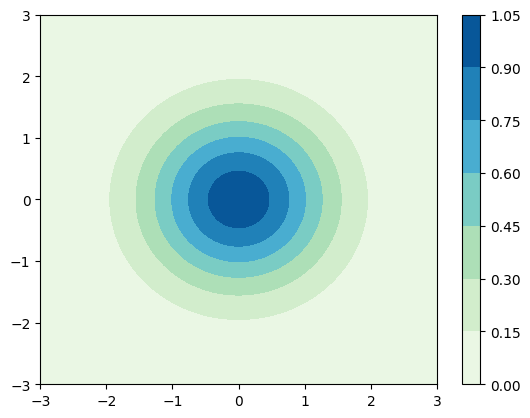

In [4]:
#write a grid space

n_points = 100

x = np.linspace(-3, 3, n_points)
y = np.linspace(-3, 3, n_points)
grid = np.meshgrid(x, y)
xys = np.stack(grid).reshape(2, n_points ** 2).T

#Z = np.array([gaussian2d(xy, *normal_dist_params) for xy in xys])
print(xys)
z = gaussian2d(xys, *normal_dist_params)

plt.contourf(x, y, z.reshape(100, 100), cmap='GnBu')
plt.colorbar()


In [5]:
from flonacomldft.utils.io_utils import get_path
import numpy as np
from scipy.optimize import curve_fit
from ase.units import kB

file = get_path()+'/unrotated_300.txt'

In [6]:
C_line = np.loadtxt(file, usecols=0)
R_line = np.loadtxt(file, usecols=1)
F_line = np.loadtxt(file, usecols=2)

bins = 401

C_grid = C_line.reshape(bins, bins)
R_grid = R_line.reshape(bins, bins)
F_grid = F_line.reshape(bins, bins)

T = 300
P_line = np.exp(-F_line/(kB*T))
P_grid = P_line.reshape(bins, bins)

In [7]:
xrange_is0 = [290,370]
yrange_is0 = [90,190]

C_is0 = C_grid[xrange_is0[0]:xrange_is0[1], yrange_is0[0]:yrange_is0[1]]
R_is0 = R_grid[xrange_is0[0]:xrange_is0[1], yrange_is0[0]:yrange_is0[1]]
F_is0 = F_grid[xrange_is0[0]:xrange_is0[1], yrange_is0[0]:yrange_is0[1]]
P_is0 = P_grid[xrange_is0[0]:xrange_is0[1], yrange_is0[0]:yrange_is0[1]]

In [8]:
xrange_is1 = [150,220]
yrange_is1 = [170,275]

C_is1 = C_grid[xrange_is1[0]:xrange_is1[1], yrange_is1[0]:yrange_is1[1]]
R_is1 = R_grid[xrange_is1[0]:xrange_is1[1], yrange_is1[0]:yrange_is1[1]]
F_is1 = F_grid[xrange_is1[0]:xrange_is1[1], yrange_is1[0]:yrange_is1[1]]
P_is1 = P_grid[xrange_is1[0]:xrange_is1[1], yrange_is1[0]:yrange_is1[1]]

In [9]:
# fig = plt.figure(figsize=(6, 6))
# ax = fig.gca(projection='3d')
# ax.plot_surface(C_is0, R_is0, P_is0, cmap='plasma')
# cset = ax.contourf(C_is0, R_is0, P_is0, zdir='z', offset=-4, cmap='plasma')
# ax.view_init(elev=5, azim=145-180)
# plt.colorbar(cset)

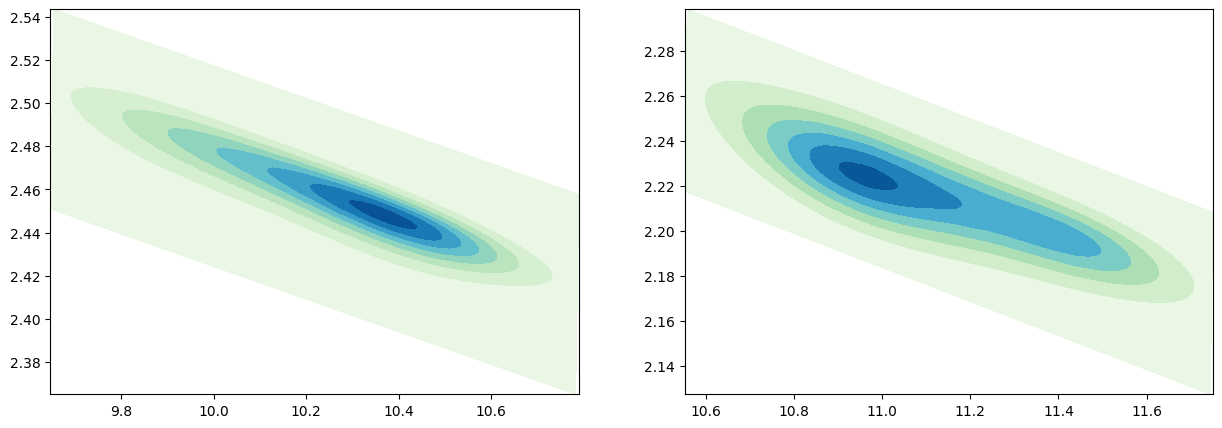

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].contourf(C_is0, R_is0, P_is0, cmap='GnBu')
axs[1].contourf(C_is1, R_is1, P_is1, cmap='GnBu')

In [11]:
C_is0_line = C_is0.reshape(-1)
R_is0_line = R_is0.reshape(-1)
F_is0_line = F_is0.reshape(-1)
P_is0_line = P_is0.reshape(-1)

C_is1_line = C_is1.reshape(-1)
R_is1_line = R_is1.reshape(-1)
F_is1_line = F_is1.reshape(-1)
P_is1_line = P_is1.reshape(-1)

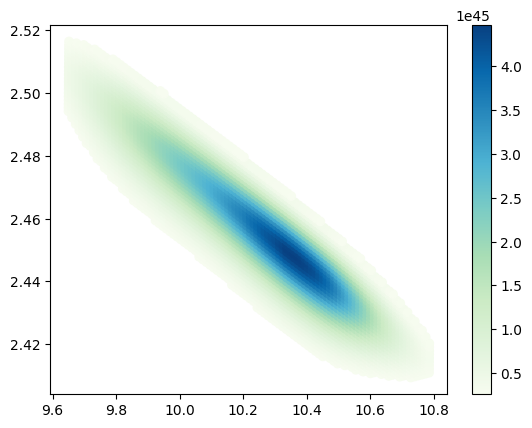

In [12]:
ind_is0 = (P_is0_line > 2.6e44)

plt.scatter(C_is0_line[ind_is0], R_is0_line[ind_is0], c=P_is0_line[ind_is0], cmap='GnBu')
plt.colorbar()

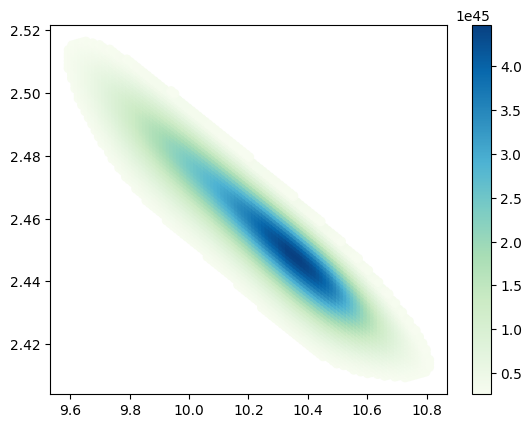

In [13]:
ind = (P_line > 2.6e44)


plt.scatter(C_line[ind], R_line[ind], c=P_line[ind], cmap='GnBu')
plt.colorbar()

/tmp/ipykernel_73475/2583320168.py:23: UserWarning: The following kwargs were not used by contour: 'linestyle'
  ax[0].contour(x, y, z.reshape(n_points, n_points), colors='k', linestyle='--', linewidths=0.3)


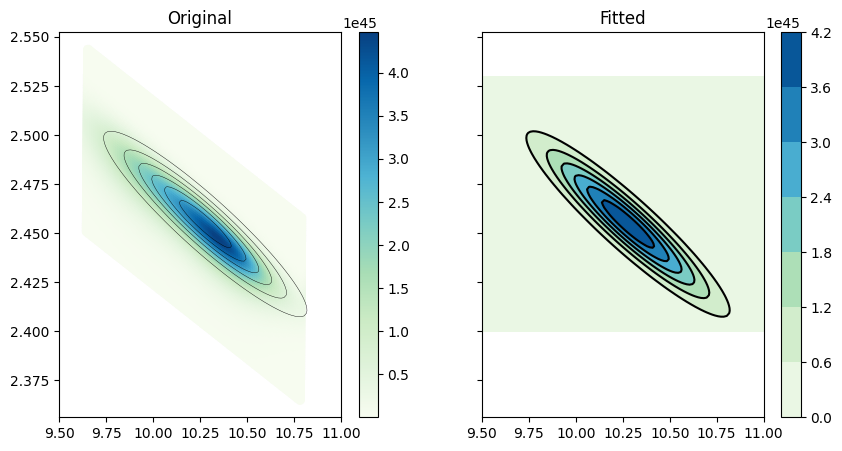

In [14]:
#data = np.stack([C_line[ind], R_line[ind], P_line[ind]], axis=1)
data = np.stack([C_is0_line, R_is0_line, P_is0_line], axis=1)
#data = np.stack([C_is0_line[ind_is0], R_is0_line[ind_is0], P_is0_line[ind_is0]], axis=1)

xy = data[:, :2]
z = data[:, 2]

params = np.array([10.4, 2.4, 51, 0, 200.0, 5952, 1e45])

popt_0, pcov_0 = curve_fit(gaussian2d, xy, z, params)

n_points = 100
x = np.linspace(9.5, 11, n_points)
y = np.linspace(2.4, 2.53, n_points)
grid = np.meshgrid(x, y)
xys = np.stack(grid).reshape(2, n_points ** 2).T

z = gaussian2d(xys, *popt_0)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
#ax[0].scatter(C_line[ind], R_line[ind], c=P_line[ind], cmap='GnBu')
ax[0].scatter(C_is0_line, R_is0_line, c=P_is0_line, cmap='GnBu')
ax[0].contour(x, y, z.reshape(n_points, n_points), colors='k', linestyle='--', linewidths=0.3)
fig.colorbar(ax[0].scatter(C_is0_line, R_is0_line, c=P_is0_line, cmap='GnBu'), ax=ax[0])
ax[0].set_title('Original')

ax[1].contourf(x, y, z.reshape(n_points, n_points), cmap='GnBu') 
ax[1].contour(x, y, z.reshape(n_points, n_points), colors='k')
ax[1].set_title('Fitted')
fig.colorbar(ax[1].contourf(x, y, z.reshape(n_points, n_points), cmap='GnBu'), ax=ax[1])

/tmp/ipykernel_73475/1788140878.py:22: UserWarning: The following kwargs were not used by contour: 'linestyle'
  ax[0].contour(x, y, z.reshape(n_points, n_points), colors='k', linestyle='--', linewidths=0.3)


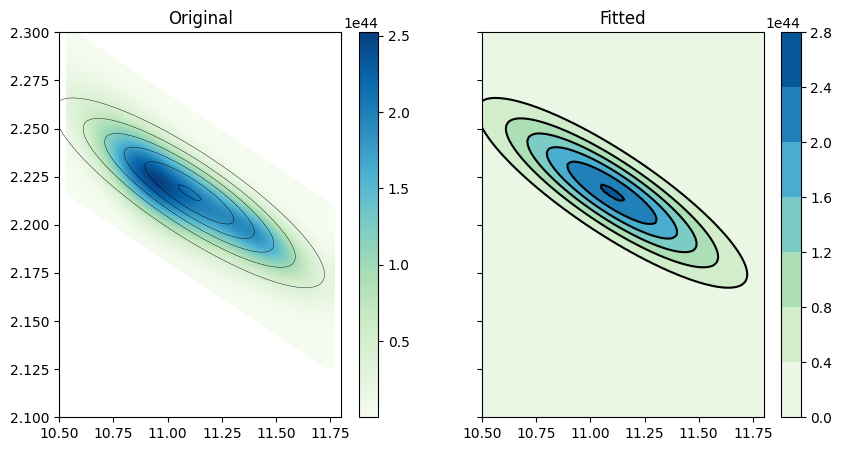

In [15]:
#data = np.stack([C_line[ind], R_line[ind], P_line[ind]], axis=1)
data = np.stack([C_is1_line, R_is1_line, P_is1_line], axis=1)

xy = data[:, :2]
z = data[:, 2]

params = np.array([11.1, 2.2, 18, 0.0, 196.0, 2884, 2e44])

popt_1, pcov_1 = curve_fit(gaussian2d, xy, z, params)

n_points = 100
x = np.linspace(10.5, 11.8, n_points)
y = np.linspace(2.1, 2.3, n_points)
grid = np.meshgrid(x, y)
xys = np.stack(grid).reshape(2, n_points ** 2).T

z = np.array([gaussian2d(xy, *popt_1) for xy in xys])

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
#ax[0].scatter(C_line[ind], R_line[ind], c=P_line[ind], cmap='GnBu')
ax[0].scatter(C_is1_line, R_is1_line, c=P_is1_line, cmap='GnBu')
ax[0].contour(x, y, z.reshape(n_points, n_points), colors='k', linestyle='--', linewidths=0.3)
fig.colorbar(ax[0].scatter(C_is1_line, R_is1_line, c=P_is1_line, cmap='GnBu'), ax=ax[0])

ax[0].set_title('Original')

ax[1].contourf(x, y, z.reshape(n_points, n_points), cmap='GnBu') 
ax[1].contour(x, y, z.reshape(n_points, n_points), colors='k')
ax[1].set_title('Fitted')
fig.colorbar(ax[1].contourf(x, y, z.reshape(n_points, n_points), cmap='GnBu'), ax=ax[1])

In [16]:
# delete extra info using ind like the first time

## Adaptive

In [17]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [18]:
def gaussian2d(XY, x0, y0, sigma_xx, sigma_xy, sigma_yx, sigma_yy, A):
    XY = XY.T
    XY = torch.tensor(XY, dtype=torch.float64, device=device)
    dx = XY[0] - x0
    dy = XY[1] - y0
    covariance_xx = sigma_xx * dx
    covariance_xy = sigma_xy * dx
    covariance_yx = sigma_yx * dy
    covariance_yy = sigma_yy * dy
    exponent = -0.5 * (covariance_xx * dx + covariance_xy * dy + covariance_yx * dx + covariance_yy * dy)
    return A * torch.exp(exponent)

In [19]:
class TargetGaussian:
    def __init__(self, mean, cov, norm, kB=kB, T=300):
        self.kB = kB
        self.T = T
        self.norm = norm
        self.mean = mean
        self.cov = cov
        self.inv_cov = np.linalg.inv(cov)
        self.popt = np.hstack([self.mean.flatten(), self.inv_cov.flatten(), self.norm])
        print(self.popt, self.mean, self.cov, self.norm)
    
    def sample(self, n_samples):
        samples = np.random.multivariate_normal(self.mean, self.cov, n_samples)
        return torch.tensor(samples, dtype=torch.float64)

    def prob(self, x):
        return torch.tensor(gaussian2d(x, *self.popt)).detach()

    def log_prob(self, x):
        return torch.log(gaussian2d(x, *self.popt)).detach()
    
    def U(self, x):
        return -self.log_prob(x)*(self.T*self.kB)

In [20]:
def from_popt_to_gauss_params(popt):
    means = popt[:2]
    inv_cov = popt[2:-1].reshape(2, 2)
    cov = np.linalg.inv(inv_cov)
    norm = popt[-1]
    return means, cov, norm

In [21]:
popt_gen = np.array([10.27, 2.45, 500, 10, 10000, 500, 1e44])
mean_gen, cov_gen, norm_gen = from_popt_to_gauss_params(popt_gen)
generator = TargetGaussian(mean_gen, cov_gen, norm_gen)

mean_0, cov_0, norm_0 = from_popt_to_gauss_params(popt_0)
target_0 = TargetGaussian(mean_0, cov_0, norm_0)

[1.027e+01 2.450e+00 5.000e+02 1.000e+01 1.000e+04 5.000e+02 1.000e+44] [10.27  2.45] [[ 3.33333333e-03 -6.66666667e-05]
 [-6.66666667e-02  3.33333333e-03]] 1e+44
[ 1.02780425e+01  2.45467097e+00  9.61212643e+01  8.31600267e+04
 -8.11142166e+04  1.26042717e+04  4.09510602e+45] [10.27804251  2.45467097] [[ 1.86822062e-06 -1.23260812e-05]
 [ 1.20228488e-05  1.42472118e-08]] 4.095106019227671e+45


tensor([[ 9.5000,  2.4000],
        [ 9.5000,  2.4013],
        [ 9.5000,  2.4026],
        ...,
        [11.0000,  2.5274],
        [11.0000,  2.5287],
        [11.0000,  2.5300]])


/tmp/ipykernel_73475/2813978529.py:13: RuntimeWarning: covariance is not positive-semidefinite.
  samples = np.random.multivariate_normal(self.mean, self.cov, n_samples)
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/torch/functional.py:568: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2228.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/tmp/ipykernel_73475/1040167257.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XY = torch.tensor(XY, dtype=torch.float64, device=device)
/tmp/ipykernel_73475/2813978529.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather t

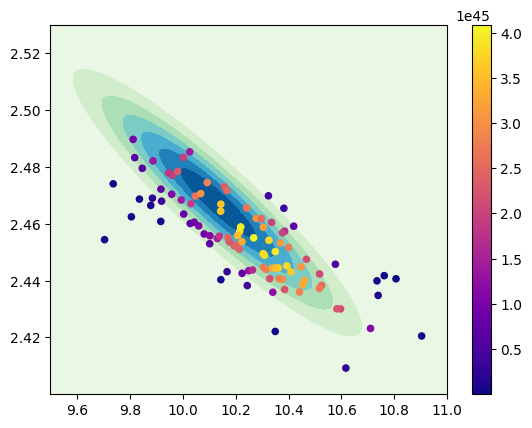

In [22]:
samples_0 = generator.sample(100)

x = torch.linspace(9.5, 11, n_points)
y = torch.linspace(2.4, 2.53, n_points)
grid = torch.meshgrid(x, y)
xys = torch.stack(grid).reshape(2, n_points ** 2).T

print(xys)

z = target_0.prob(xys)

plt.contourf(x.detach().numpy(), y.detach().numpy(), z.reshape(n_points, n_points).detach().numpy(), cmap='GnBu')
plt.scatter(samples_0[:, 0], samples_0[:, 1], c=target_0.prob(samples_0), cmap='plasma', s=20)
plt.colorbar()

In [23]:
n_samples = 10

generator_samples = generator.sample(n_samples)
generator_us = torch.tensor([target_0.U(sample) for sample in generator_samples])
id_mode = torch.ones(n_samples)
dataset = torch.cat([generator_samples.T, generator_us.reshape(1, -1), id_mode.reshape(1, -1)]).T


train = dataset[:int(0.8 * len(dataset))]
test = dataset[int(0.8 * len(dataset)):] 

/tmp/ipykernel_73475/2813978529.py:13: RuntimeWarning: covariance is not positive-semidefinite.
  samples = np.random.multivariate_normal(self.mean, self.cov, n_samples)
/tmp/ipykernel_73475/1040167257.py:2: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matricesor `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2318.)
  XY = XY.T
/tmp/ipykernel_73475/1040167257.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XY = torch.tensor(XY, dtype=torch.float64, device=device)


In [24]:
target_energy = lambda x: target_0.U(x)
mlp_dic = {'model': target_energy}

In [25]:
from flonacomldft.models.real_nvp import RealNVP_MLP
from flonacomldft.train_flow_from_data import train_flow

In [26]:
n_blocks = 4
hidden_dim = 64
hidden_depth = 4

model = RealNVP_MLP(2,
                    n_blocks=n_blocks,
                    block_depth=1,
                    init_weight_scale=1e-3,
                    base_cov=None,
                    hidden_dim=hidden_dim,
                    hidden_depth=hidden_depth,
                    device=device,
                    )

In [27]:
train = train.type(torch.float32)
test = test.type(torch.float32)

In [28]:
n_iter = 10000

In [29]:
flow_dic = train_flow(
    model,
    train,
    test,
    dim=2,
    n_iter=n_iter,
    lr=1e-3,
    use_scheduler=True,
    step_schedule=int(n_iter/3),
    save_splits=10,
    grad_clip=1e4,
    with_tqdm=False,
    compute_part_ratio=True,
    energy_type='mlp',
    mlp_model=mlp_dic['model'],
    n_prop=1000,
    path='',
)

t=0.0e+00 	 loss: 56.30	Gd: 5e+01	lr: 1.00e-03	part ratio: nan


/tmp/ipykernel_73475/1040167257.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XY = torch.tensor(XY, dtype=torch.float64, device=device)


t=1.0e+03 	 loss: 1.22	Gd: 7e-01	lr: 1.00e-03	part ratio: 1.02e-02
t=2.0e+03 	 loss: 0.52	Gd: 1e+00	lr: 1.00e-03	part ratio: 1.31e-02
t=3.0e+03 	 loss: 0.33	Gd: 3e-01	lr: 1.00e-03	part ratio: 2.37e-02
t=4.0e+03 	 loss: 0.22	Gd: 3e-01	lr: 5.00e-04	part ratio: 3.07e-02
t=5.0e+03 	 loss: 0.13	Gd: 7e-01	lr: 5.00e-04	part ratio: 2.77e-02
t=6.0e+03 	 loss: 0.05	Gd: 2e-01	lr: 5.00e-04	part ratio: 2.59e-02
t=7.0e+03 	 loss: -0.01	Gd: 2e-01	lr: 2.50e-04	part ratio: 2.67e-02
t=8.0e+03 	 loss: -0.04	Gd: 1e-01	lr: 2.50e-04	part ratio: 3.60e-02
t=9.0e+03 	 loss: -0.07	Gd: 4e-01	lr: 2.50e-04	part ratio: 3.10e-02


In [30]:
lims = {'x_min':8.5, 'x_max':12, 'y_min':2.40, 'y_max':2.5}
device = 'cpu'

def set_plot(ax, n_points, target_log_prob, prop_log_prob=None, lims=lims):
    
    x_range = torch.linspace(lims['x_min'], lims['x_max'], n_points, device=device)

    if lims['y_min'] is None:
        y_range = x_range.clone()
    else:
        y_range = torch.linspace(lims['y_min'], lims['y_max'], n_points, device=device)

    grid = torch.meshgrid(x_range, y_range)
    xys = torch.stack(grid).reshape(2, n_points ** 2).T.to(device)

    Us_target = target_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

    if ax is None:
        plt.figure()
    else:
        plt.sca(ax)
    #plt.axis('off')

    plt.contourf(x_range, y_range, np.exp(Us_target)
    # np.log( - Us_target + Us_target.max() + 1)
    , 10, cmap='GnBu')
    ax.set_aspect('equal')

    if prop_log_prob is not None:
        Us_prop = prop_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

        plt.contour(x_range, y_range, np.exp(Us_prop), 10, colors='k', linestyles=':', alpha=0.5)